<a href="https://colab.research.google.com/github/jennyshin01/python/blob/%EC%BD%94%EB%9E%A9%EC%97%B0%EA%B2%B0%ED%8C%8C%EC%9D%BC/%EB%B3%91%EC%88%98%EB%9D%A0_%EA%B8%B0%EB%A7%90%EA%B3%A0%EC%82%AC_%EC%9E%91%EC%97%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#예제 5-1 타이타닉 데이터 변수의 이름과 각 변수의 사례 수
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset(('titanic'))
print(df.info())
print(df.head())

#데이터 생략 없이 쓰는 법
pd.set_option('display.max_columns', None)
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  

survived
0    549
1    342
Name: count, dtype: int64
alive
no     549
yes    342
Name: count, dtype: int64


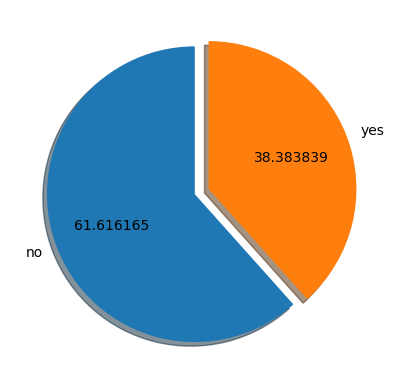



sex
male      577
female    314
Name: count, dtype: int64


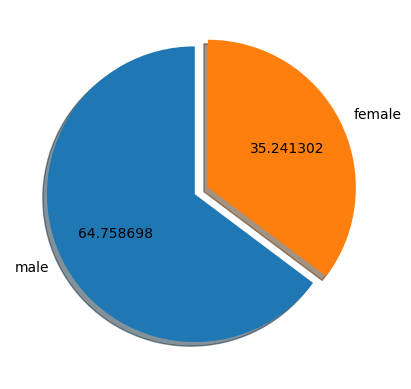



who
man      537
woman    271
child     83
Name: count, dtype: int64


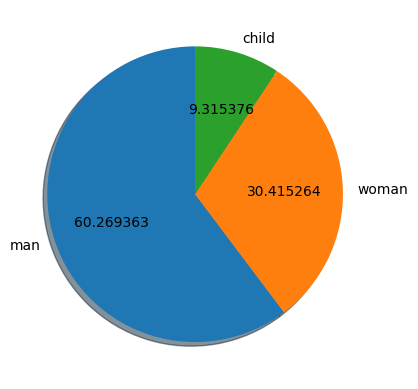



alone
True     537
False    354
Name: count, dtype: int64


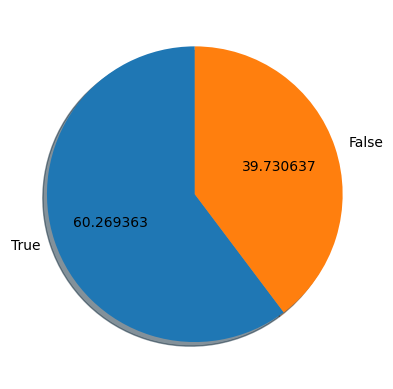

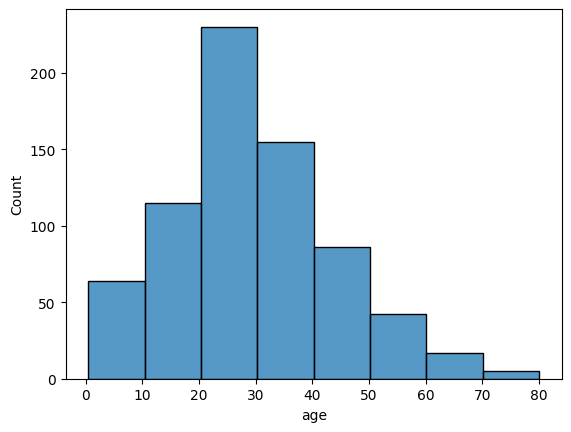

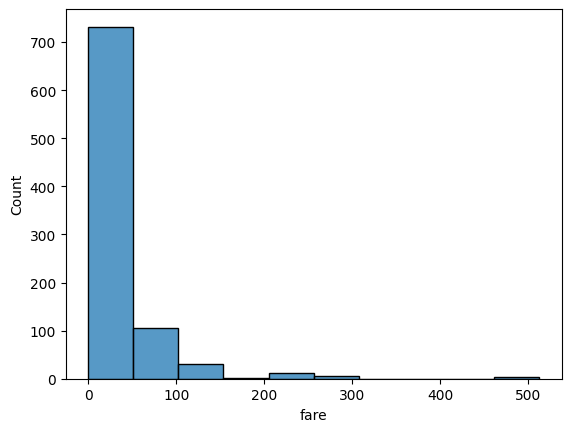

In [9]:
#예제 5-2 데이터에 대한 기본정보
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#타이타닉 데이터 df로 가져오기
df = sns.load_dataset(('titanic'))

#생존자와 사망자 사례 수
print(df["survived"].value_counts())
print(df['alive'].value_counts())

#생존 여부 구성비 <<원그래프로
plt.pie(df['alive'].value_counts(), labels=['no','yes'],
        explode=(0, 0.1), startangle=90, shadow=True, autopct='%1f')
plt.show()

print('\n')

#성별 사례 수 확인
print(df['sex'].value_counts())

#성별 구성비 <<원그래프로
plt.pie(df['sex'].value_counts(), labels=['male','female'],
        explode=(0, 0.1), startangle=90, shadow=True, autopct='%1f')
plt.show()

print('\n')

#성별, 아이별 사례 수
print(df['who'].value_counts())

#성별, 아이별 구성비 (원그래프)
plt.pie(df['who'].value_counts(), labels=['man','woman','child'],
        startangle=90, shadow=True, autopct='%1f' )
plt.show()

print('\n')

#혼자 탑승 여부에 따른 사례 수 와 그래프
print(df['alone'].value_counts())

#혼자 탑승비에 따른 구성비 << 원그래프
plt.pie(df['alone'].value_counts(), labels=['True', 'False'],
        startangle=90, shadow=True, autopct='%1f')
plt.show()

print('\n')

#나이 분포와 요금분포
sns.histplot(df, x='age', bins = 8)
plt.show()

sns.histplot(df, x = 'fare', bins = 10)
plt.show()

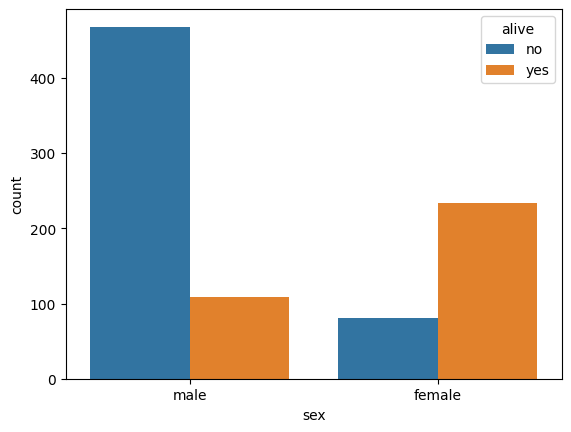

alive    no  yes  All
sex                  
female   81  233  314
male    468  109  577
All     549  342  891




In [10]:
#예제5-3
#성별 생존자 수와 생존율의 비교
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset(('titanic'))

#성별 생존여부
sns.countplot(data=df, x=df['sex'], hue=df['alive'])
plt.show()

#성별 생존 여부에 따른 교차표
print(pd.crosstab(df['sex'], df['alive'], margins=True))
print('\n')

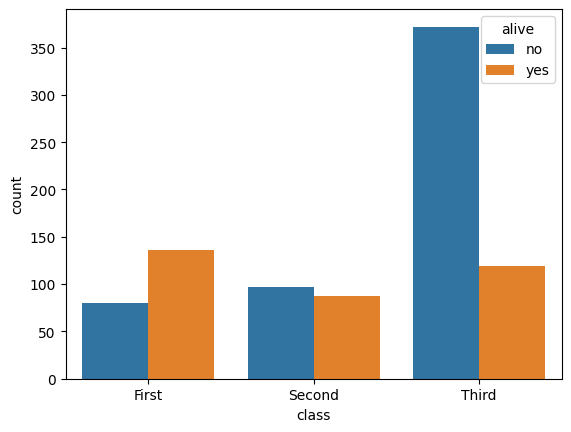

alive    no  yes  All
class                
First    80  136  216
Second   97   87  184
Third   372  119  491
All     549  342  891




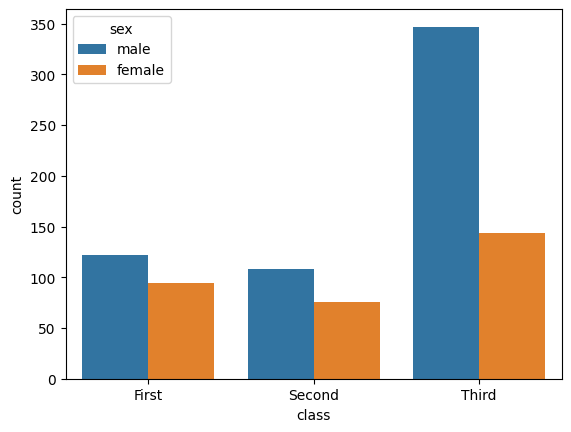

class  First      Second       Third       All
sex   female male female male female male     
alive                                         
no         3   77      6   91     72  300  549
yes       91   45     70   17     72   47  342
All       94  122     76  108    144  347  891
n


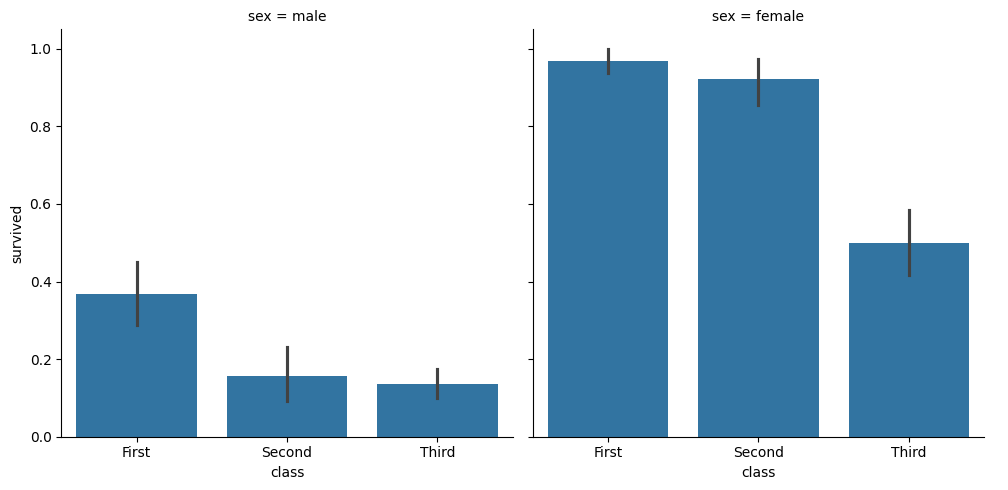

In [14]:
#예제5-4
#객실 등급별 생존자 수와 생존율의 비교
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset(('titanic'))

#객실 등급별 생존여부의 막대그래프
sns.countplot(data=df, x=df['class'], hue = df['alive'])
plt.show()

#객실등급별 생존여부에 따른 교차표
print(pd.crosstab(df['class'], df['alive'], margins=True))
print('\n')

#객실 등급별 성별인원
sns.countplot(data=df, x=df['class'], hue=df['sex'])
plt.show()

#객실등급별 성별에 따른 교차표
#생존여부에 따른 객실등급과 성별의 교차표
print(pd.crosstab(df['alive'], [df['class'], df['sex']], margins=True))
print('n')

#객실등급별 성별 생존율
sns.catplot(x='class', y='survived', col='sex', data=df, kind='bar')
plt.show()

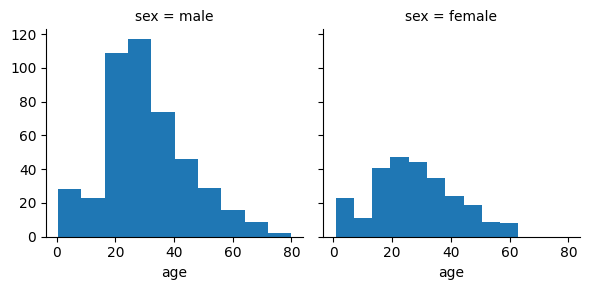

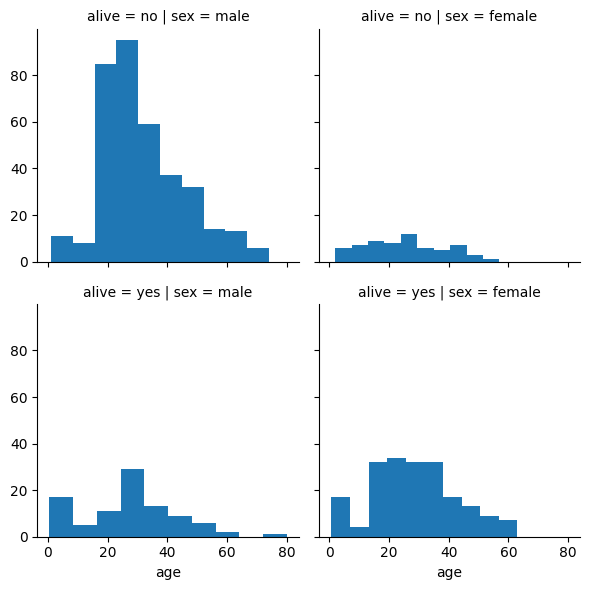

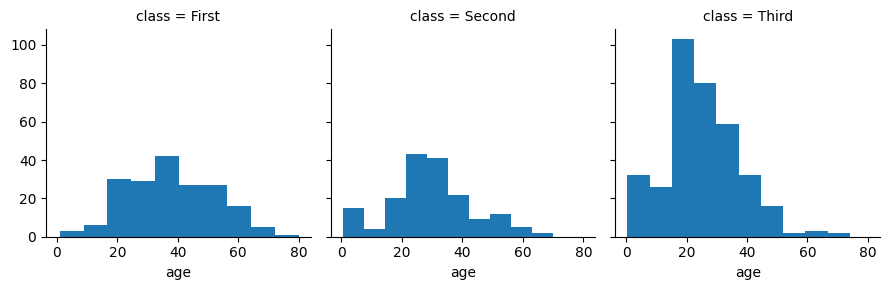

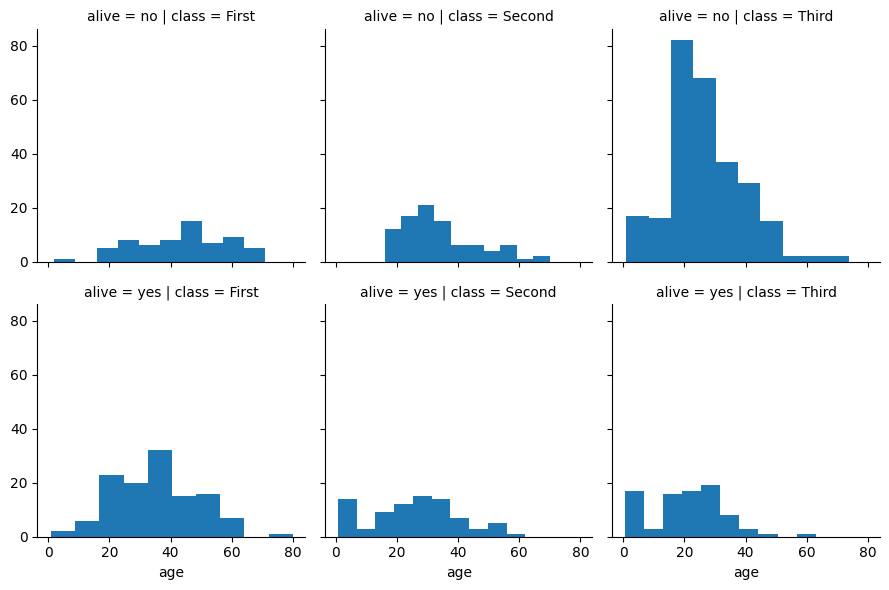

In [15]:
#예제 5-5
#연령별 생존자 수와 생존율의 비교

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset(('titanic'))

#성별에 따른 나이분포
g = sns.FacetGrid(df, col='sex')
g.map(plt.hist, 'age')
plt.show()

#생존여부에 따른 나이분포
g = sns.FacetGrid(df, col='sex', row='alive')
g.map(plt.hist, 'age')
plt.show()

#객실 등급별 나이분포
g = sns.FacetGrid(df, col='class')
g.map(plt.hist, 'age')
plt.show()

#객실 등급별 생존여부에 따른 나이 분포
g = sns.FacetGrid(df, col='class', row='alive')
g.map(plt.hist, 'age')
plt.show()

In [28]:
#워드클라우드 _ 단어를 시각화하기 위해 사용, 빈도수나 중요도에 따라 부각시켜서 나타냄

import os
import glob
f1 = []
for file in glob.glob('*.txt'):
  with open(file, 'r', newline='') as filereader:
    for row in filereader:
      contents = row.split()
      for i in contents:
        contents = i.strip('.').strip(',').strip('')
        f1.append(contents)

f1

['작은',
 '일에',
 '성실한',
 '사람은',
 '큰일에도',
 '성실하고',
 '작은일에',
 '정직하지',
 '못한',
 '사람은',
 '큰일에도',
 '정직하지',
 '못하다',
 '누가복음',
 '16:10',
 '변함없이',
 '서로',
 '사랑하는',
 '이가',
 '친구이며',
 '위급할때',
 '서로',
 '돕는',
 '이가',
 '형제다',
 '잠언',
 '17:17']

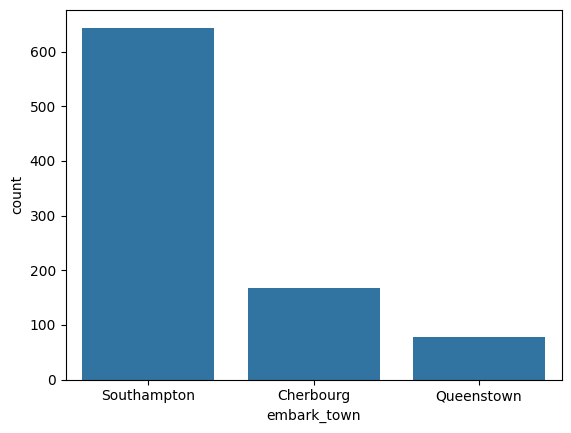

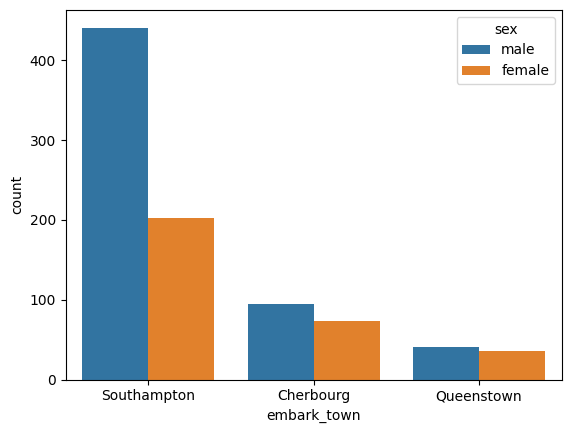

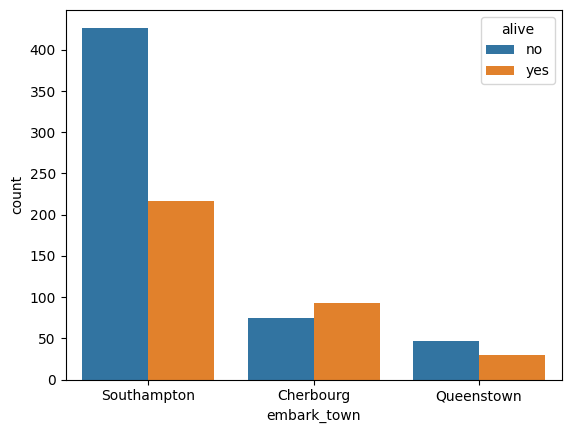

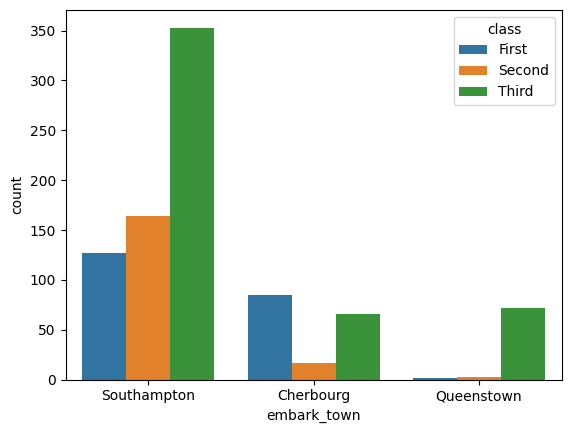

embark_town Cherbourg      Queenstown      Southampton       All
sex            female male     female male      female male     
alive                                                           
no                  9   66          9   38          63  364  549
yes                64   29         27    3         140   77  340
All                73   95         36   41         203  441  889
n
embark_town Cherbourg         Queenstown        Southampton            All
pclass              1   2   3          1  2   3           1    2    3     
alive                                                                     
no                 26   8  41          1  1  45          53   88  286  549
yes                59   9  25          1  2  27          74   76   67  340
All                85  17  66          2  3  72         127  164  353  889


In [16]:
#예제5-6
#탑승도시별 생존자 수와 생존율의 비교

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset(('titanic'))

#도시별 탑승인원
sns.countplot(df, x='embark_town')
plt.show()

#탑승도시별 성별 구분
sns.countplot(df, x = 'embark_town', hue = 'sex')
plt.show()

#탑승도시별 생존여부
sns.countplot(df, x = 'embark_town', hue='alive')
plt.show()

#탑승도시별 등급구분
sns.countplot(df, x = 'embark_town', hue = 'class')
plt.show()

#도시별 성별 생존여부의 사례수
print(pd.crosstab(df['alive'], [df['embark_town'], df['sex']], margins=True))
print('n')

#도시별 등급별 생존여부의 사례수
print(pd.crosstab(df['alive'], [df['embark_town'], df['pclass']], margins=True))

In [36]:
# proverb.txt 저장
contents = """작은 일에 성실한 사람은 큰일에도 성실하고,
작은일에 정직하지 못한 사람은 큰일에도 정직하지 못하다.
누가복음 16:10
변함없이 서로 사랑하는 이가 친구이며
위급할때 서로 돕는 이가 형제다.
잠언 17:17"""

file = open("./proverb.txt", 'w', encoding='utf-8')
file.write(contents)
file.close()  # 괄호 필수!

# hello.txt 입력받아 저장
file = open("./hello.txt", 'a', encoding='utf-8')
while True:
    content = input()
    if not content:
        break
    file.write(content + '\n')
    print(content)
file.close()

# fruits.txt 저장
fruits = ['apple', 'apple', 'apple', 'banana', 'banana', 'orange', 'orange', 'mango', 'orange', 'orange', 'orange']
index = len(fruits)
file = open("./fruits.txt", 'a', encoding='utf-8')
for i in range(index):
    if i < (index - 1):
        file.write(fruits[i] + '\t')
    else:
        file.write(fruits[i] + '\n')
file.close()

나는
나는
똥이다
똥이다
멍멍멍
멍멍멍
개이다
개이다
 
 
그만
그만
ㅇ
ㅇ
ㄷ
ㄷ
ㅈ
ㅈ
ㅂ
ㅂ



In [27]:
#단어 빈도수 구하기 전 준비 _ 마침표, 쉼표, 공백 제거, 사용하지 않는 불용어 제거, 조사, '합니다', '하세요' 제거
import os
import glob

f1 = []
for file in glob.glob('*.txt'):
  with open(file, 'r', newline='') as filereader:
    for row in filereader:
      contents = row.split()
      for i in contents:
        contents = i.strip('.').strip(',').strip('').strip('를').strip('을').strip("''")
        contents = contents.strip('합니다').strip('하세요')
        contents = contents.strip('에')
        f1.append(contents)
f1

['작은',
 '일',
 '성실한',
 '사람은',
 '큰일에도',
 '성실하고',
 '작은일',
 '정직하지',
 '못한',
 '사람은',
 '큰일에도',
 '정직하지',
 '못',
 '누가복음',
 '16:10',
 '변함없이',
 '서로',
 '사랑하는',
 '이가',
 '친구이며',
 '위급할때',
 '서로',
 '돕는',
 '이가',
 '형제',
 '잠언',
 '17:17']

In [30]:
#단어별 갯수 세어 표시하기_ counter 모듈 사용
from collections import Counter
f1
word_counts = Counter(f1)
dict(word_counts)

#word_counts.items()
wc = sorted(word_counts.items(), key=lambda count:count[1], reverse=True)
wc

import pandas as pd
wcdf = pd.DataFrame(wc)
wcdf.columns = ['word', 'freq']

wcdf1 = wcdf.set_index('word')
wcdf1.head()

,freq
word,
사람은,2
큰일에도,2
정직하지,2
서로,2
이가,2


In [31]:
#폰트와 글꼴 설정
import pandas as pd
import numpy as np
import re

#한글표현을 위해서 폰트 설치
%config InlineBackend.figure_format='retina'
!apt -qq -y install fonts-nanum >/dev/null
import matplotlib.font_manager as fm

#프리젠테이션 ttf 사용
fontpath = '/content/Freesentation-5Medium.ttf'
font = fm.FontProperties(fname=fontpath, size=9)

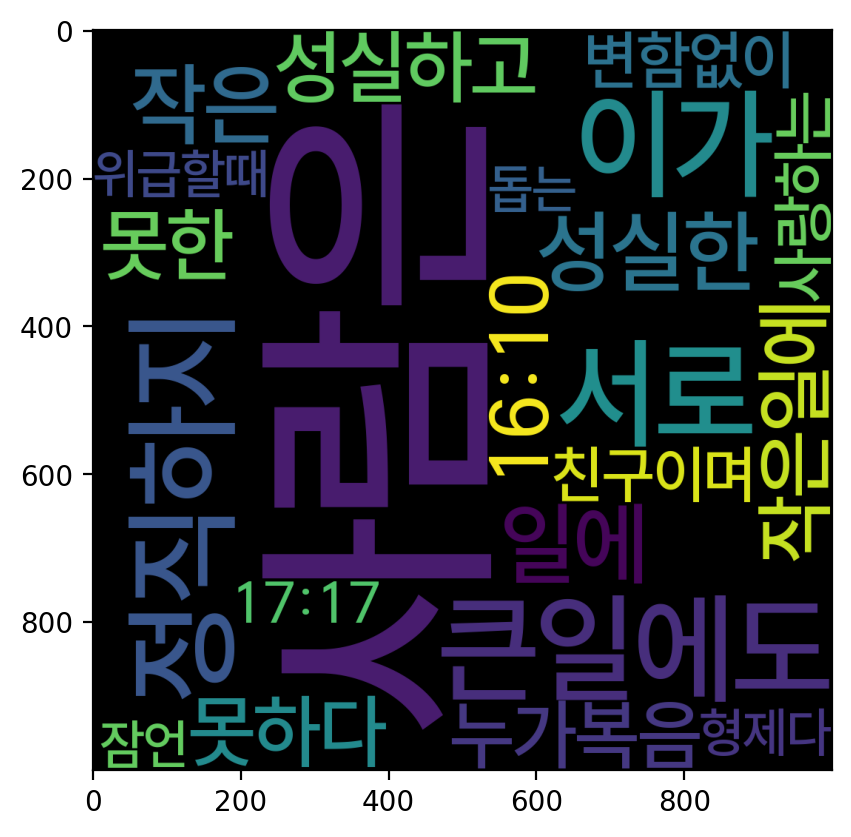

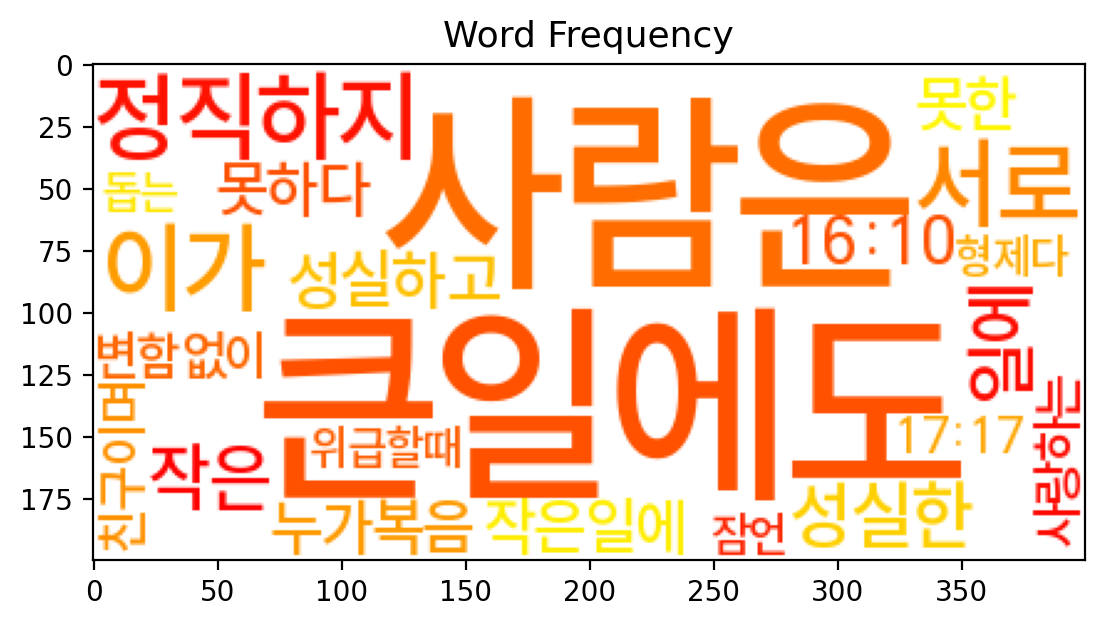

In [38]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

word_freq=wcdf1['freq'].to_dict()
wordcloud=WordCloud(font_path='/content/Freesentation-5Medium.ttf', width=1000,height=1000).generate_from_frequencies(word_freq)

plt.imshow(wordcloud)
plt.show()

wordcloud = WordCloud(font_path='/content/Freesentation-5Medium.ttf',
                     background_color='white', colormap='autumn').generate_from_frequencies(word_freq)

plt.imshow(wordcloud)
plt.title('Word Frequency', size=13) #제목지정
plt.show()

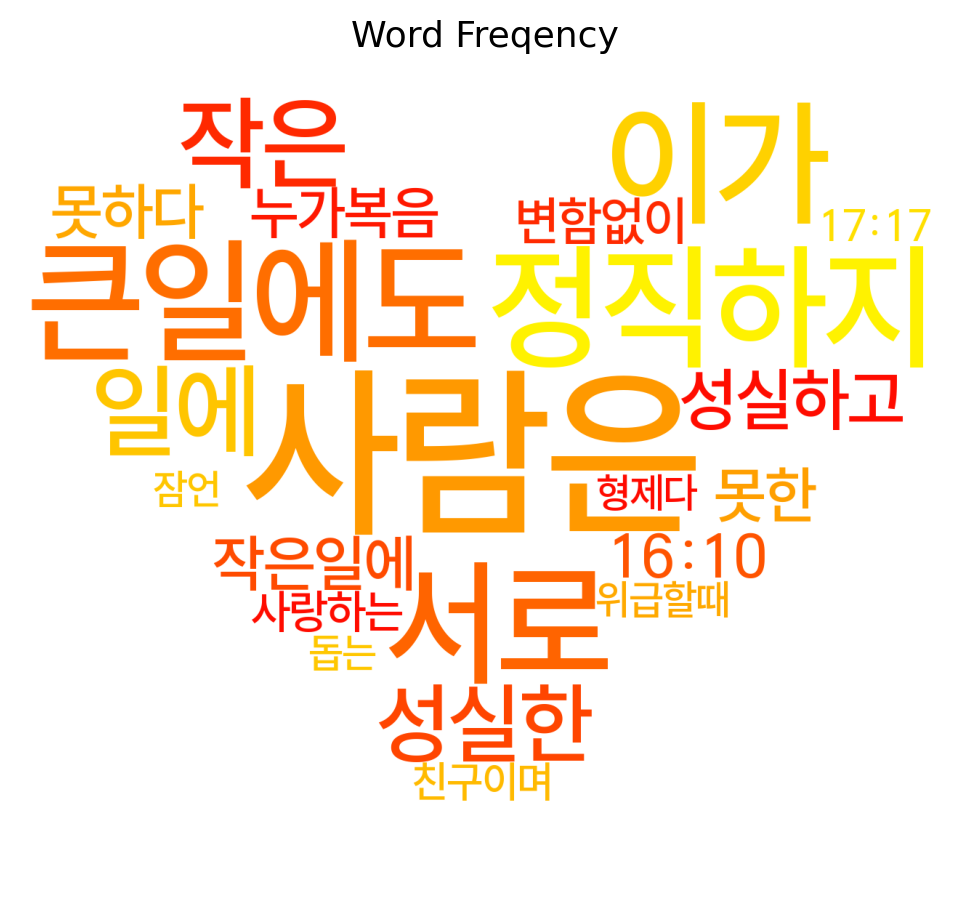

In [39]:
from PIL import Image
import numpy as np
im = Image.open('/content/heart.png')
mask_arr = np.array(im)

wordcloud = WordCloud(font_path='/content/Freesentation-5Medium.ttf',
                      background_color='white', colormap='autumn',
                      width=700, height=700, random_state = 43,
                      mask = mask_arr, prefer_horizontal=True).generate_from_frequencies(word_freq)

plt.figure(figsize=(6, 6))
plt.imshow(wordcloud)
plt.title('Word Freqency', size=13)
plt.axis('off')
plt.show()